In [35]:
import pandas as pd
import numpy as np
import pickle
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings("ignore")
import joblib

In [36]:
import os
os.makedirs("../Clean", exist_ok=True)
os.makedirs("../Vectorización", exist_ok=True)

In [37]:
df = pd.read_csv("../Preprocesamiento/training_limpio.csv")

In [38]:
df.head()

,sentiment,id,date,query,user,text,long_caracteres_raw,texto_limpio,long_caracteres,conteo_palabras
0,-1,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",115,thats bummer shoulda got david carr third day,45,8
1,-1,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,111,upset cant update facebook texting might cry r...,74,12
2,-1,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,89,dived many times ball managed save rest go bounds,49,9
3,-1,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,47,whole body feels itchy like fire,32,6
4,-1,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",111,behaving im mad cant see,24,5


In [39]:
df.describe() 


,sentiment,id,long_caracteres_raw,long_caracteres,conteo_palabras
count,1.592691e+06,1.592691e+06,1.592691e+06,1.592691e+06,1.592691e+06
mean,1.067376e-05,1.998822e+09,7.433367e+01,4.282969e+01,7.141488e+00
std,1.000000e+00,1.935910e+08,3.633555e+01,2.390052e+01,3.877364e+00
min,-1.000000e+00,1.467810e+09,6.000000e+00,1.000000e+00,1.000000e+00
25%,-1.000000e+00,1.956916e+09,4.400000e+01,2.300000e+01,4.000000e+00
50%,1.000000e+00,2.002112e+09,6.900000e+01,3.900000e+01,7.000000e+00
75%,1.000000e+00,2.177066e+09,1.040000e+02,6.000000e+01,1.000000e+01
max,1.000000e+00,2.329206e+09,3.740000e+02,3.490000e+02,3.700000e+01


In [40]:
X=df["texto_limpio"]
y=df["sentiment"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [42]:
X_train.shape[0]

1274152

In [43]:
X_test.shape[0]

318539

In [44]:
print("Balance de clases en train:")
print(y_train.value_counts(normalize=True))
print("\nBalance de clases en test:")
print(y_test.value_counts(normalize=True))

Balance de clases en train:
sentiment
 1    0.500005
-1    0.499995
Name: proportion, dtype: float64

Balance de clases en test:
sentiment
 1    0.500005
-1    0.499995
Name: proportion, dtype: float64


In [45]:
joblib.dump(X_train, "../Clean/X_train_clean.pkl")
joblib.dump(X_test, "../Clean/X_test_clean.pkl")
joblib.dump(y_train, "../Clean/y_train_clean.pkl")
joblib.dump(y_test, "../Clean/y_test_clean.pkl")

['../Clean/y_test_clean.pkl']

Vectorización con TF-IDF 

In [46]:
tfidf=TfidfVectorizer(max_features=200000,min_df=5, max_df=0.9,  ngram_range=(1, 2),stop_words=None)

In [47]:
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

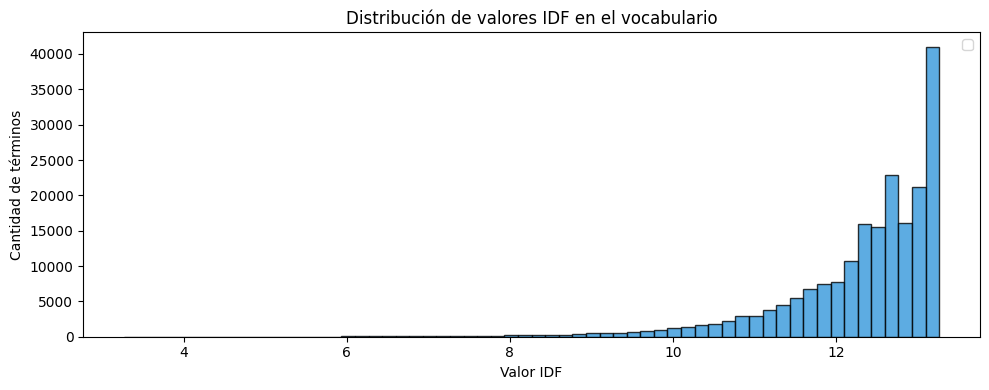

In [48]:
plt.figure(figsize=(10, 4))
plt.hist( tfidf.idf_, bins=60, color='#3498db', edgecolor='black', alpha=0.8)
plt.title('Distribución de valores IDF en el vocabulario')
plt.xlabel('Valor IDF')
plt.ylabel('Cantidad de términos')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
prom_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
feature_names = np.array(tfidf.get_feature_names_out())
top_idx = prom_tfidf.argsort()[::-1][:10]

top_terms = pd.DataFrame({ "Palabra": feature_names[top_idx],"tfidf_promedio": prom_tfidf[top_idx]})

In [50]:
top_terms

,Palabra,tfidf_promedio
0,im,0.013267
1,good,0.009029
2,day,0.007975
3,get,0.007074
4,like,0.007044
5,work,0.006967
6,love,0.006959
7,go,0.006921
8,dont,0.006507
9,going,0.006444


In [51]:
joblib.dump(tfidf, "../Vectorización/tfidf_vectorizer.pkl")
joblib.dump(X_train_tfidf, "../Vectorización/X_train_tfidf.pkl")
joblib.dump(X_test_tfidf, "../Vectorización/X_test_tfidf.pkl")
joblib.dump(y_train, "../Vectorización/y_train.pkl")
joblib.dump(y_test, "../Vectorización/y_test.pkl")

['../Vectorización/y_test.pkl']

Vectorización con BoW

In [52]:
from sklearn.feature_extraction.text import CountVectorizer

In [53]:
bow = CountVectorizer(max_features=200000, min_df=5, max_df=0.9, stop_words=None)

In [54]:
X_train_bow = bow.fit_transform(X_train)

In [55]:
X_test_bow = bow.transform(X_test)

In [56]:
X_train_bow.shape

(1274152, 47889)

In [57]:
X_test_bow.shape

(318539, 47889)

In [58]:
tf_global_bow = np.asarray(X_train_bow.sum(axis=0)).ravel()

top_tf_idx = tf_global_bow.argsort()[::-1][:10]

tabla_tf = pd.DataFrame({
    "Palabra": feature_names[top_tf_idx],
    "frecuencia_total": tf_global_bow[top_tf_idx]
})

In [59]:
tabla_tf

,Palabra,frecuencia_total
0,called cops,142292
1,bought copy,71527
2,back til,68072
3,boooooring,65416
4,chewie,62212
5,born day,58481
6,bc damn,53661
7,dropping say,51548
8,bothered go,51311
9,chun,51062


In [60]:
joblib.dump(bow, "../Vectorización/bow_vectorizer.pkl")
joblib.dump(X_train_bow, "../Vectorización/X_train_bow.pkl")
joblib.dump(X_test_bow, "../Vectorización/X_test_bow.pkl")

['../Vectorización/X_test_bow.pkl']